# **Corriger les valeurs manquantes **

Plusieurs solution:

1- Ne rien faire, ignorer les valeurs manquantes.

2- Utiliser uniquement les colonnes avec un taux de remplissage spécifique.


3- Supprimer les lignes avec les valeurs manquantes.


4- Imputer une valeur manquante par une valeur numérique ou textuelle

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Remplacez 'Mon_Dossier/mon_fichier.csv' par le chemin réel de votre fichier sur Google Drive
file_path = '/content/drive/My Drive/formation_personnelle/data_csv/donnees_manquantes.csv'

try:
    df = pd.read_csv(file_path, sep=";")
    print(f"Fichier '{file_path}' chargé avec succès.")
    display(df.head())
except FileNotFoundError:
    print(f"Erreur: Le fichier '{file_path}' n'a pas été trouvé. Veuillez vérifier le chemin.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement du fichier: {e}")

Mounted at /content/drive
Fichier '/content/drive/My Drive/formation_personnelle/data_csv/donnees_manquantes.csv' chargé avec succès.


,id_prod,date,session_id,client_id,prix
0,A_6764,2021-05-03 12:00:00,4_6970,5_7398,NaN
1,B_2445,2021-12-12 13:32:00,S_7861,6_703,"318,72"
2,NaN,NaN,NaN,D_8184,NaN
3,1_6518,2021-01-28 00:29:00,NaN,D_422,"101,46"
4,2_9410,2021-07-07 00:13:00,4_6417,D_6161,NaN


# **Identification des valeurs manquantes**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_prod     200 non-null    object
 1   date        197 non-null    object
 2   session_id  198 non-null    object
 3   client_id   200 non-null    object
 4   prix        187 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [4]:
df.isna().sum()

,0
id_prod,50
date,53
session_id,52
client_id,50
prix,63


<Axes: >

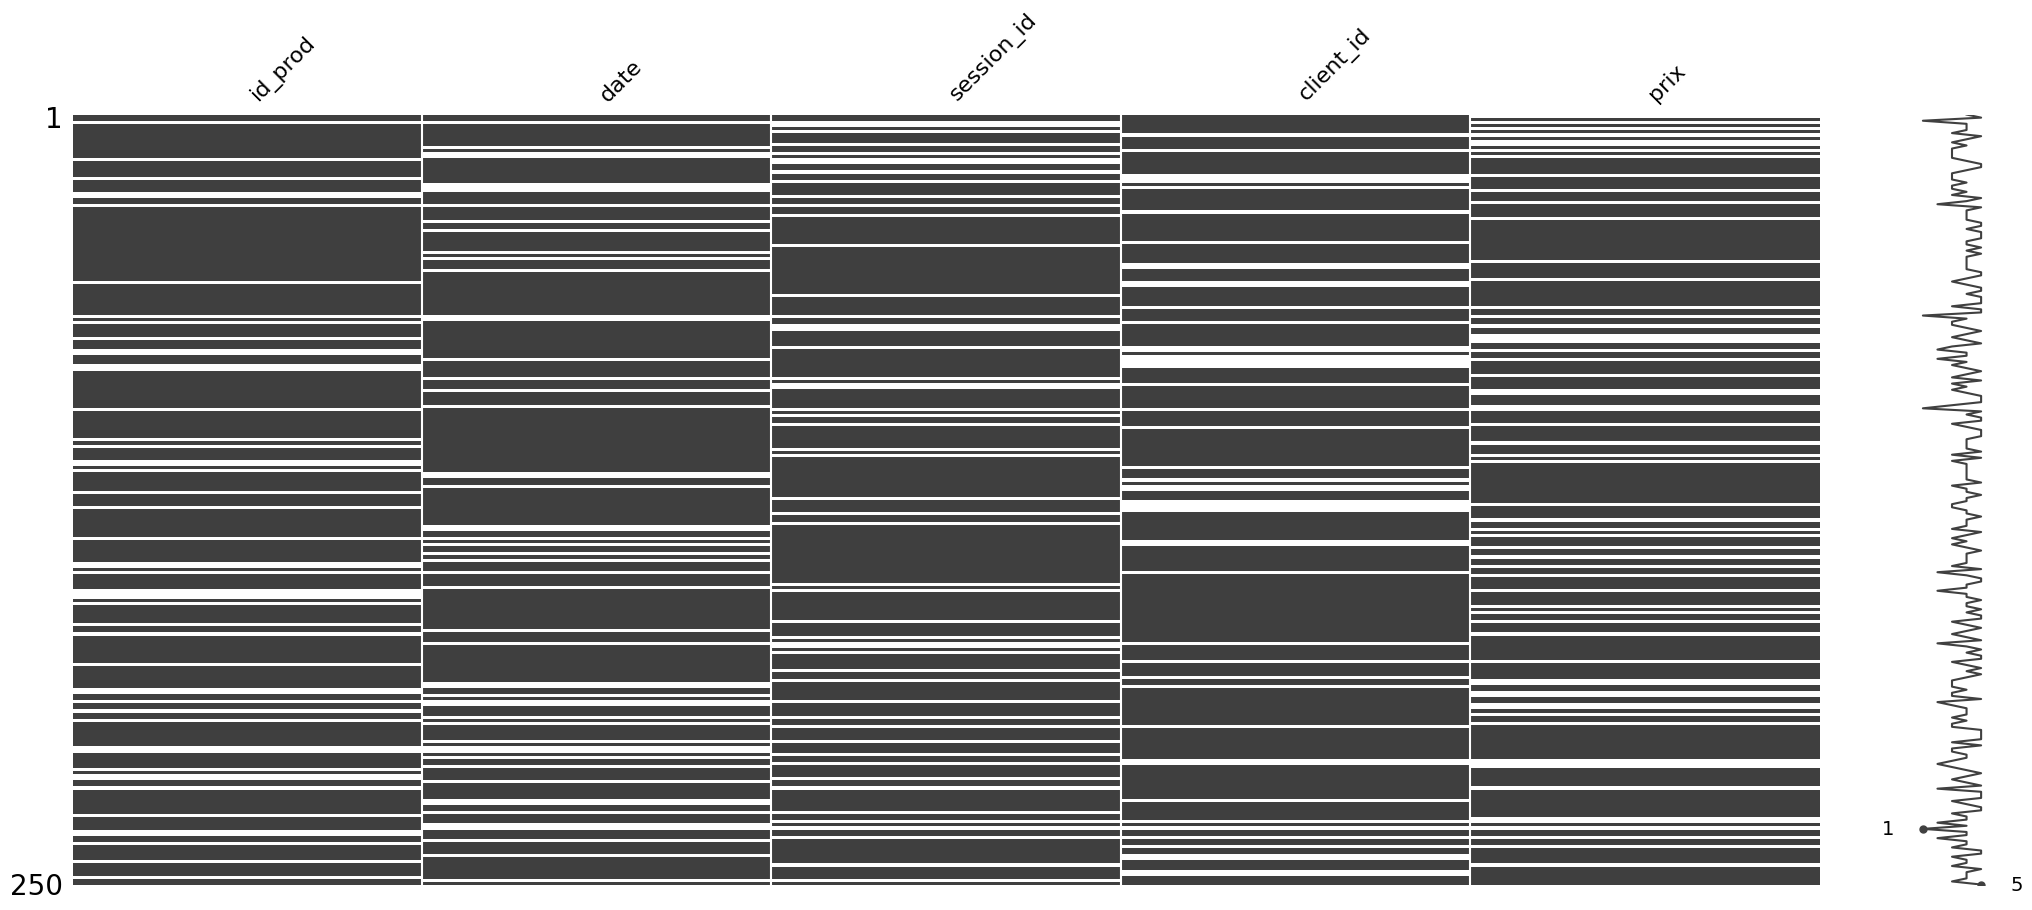

In [5]:
import missingno as msno  #Bibliothèque qui permet d'afficher la localisation des NA.
%matplotlib inline
msno.matrix(df)

# Imputation valeurs **manquantes**



*   Valeurs constantes
*   Calculs d'aggrégation


*   Méthodes d'imputation


In [6]:
#Valeurs constantes
df["prix"].fillna('Non renseigné', inplace = True)
df["prix"].value_counts()

/tmp/ipython-input-3681086371.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["prix"].fillna('Non renseigné', inplace = True)


,count
prix,
Non renseigné,63
"318,72",1
"101,46",1
"230,97",1
"485,02",1
...,...
"466,36",1
"214,32",1
"221,84",1


# Calcul d'agrégation

In [7]:
# Remplacez 'Mon_Dossier/mon_fichier.csv' par le chemin réel de votre fichier sur Google Drive
file_path = '/content/drive/My Drive/formation_personnelle/data_csv/base_clients.csv'

try:
    df = pd.read_csv(file_path, sep=";")
    print(f"Fichier '{file_path}' chargé avec succès.")
    display(df.head())
except FileNotFoundError:
    print(f"Erreur: Le fichier '{file_path}' n'a pas été trouvé. Veuillez vérifier le chemin.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement du fichier: {e}")

Fichier '/content/drive/My Drive/formation_personnelle/data_csv/base_clients.csv' chargé avec succès.


,id_client,genre,annee_naissance
0,C0001,f,1951
1,C0002,h,1964
2,C0003,f,1990
3,C0004,h,1973
4,C0005,f,1963


Récupérer la moyenne des années de naissance si on remarque des NA. Une fois la moyenne calculée, on l'impute dans le jeu de données dans la colonnes annee_naissance.

In [8]:
clients = df

In [10]:
moyenne_Birth = clients["annee_naissance"].mean()
clients2 = clients["annee_naissance"].fillna(moyenne_Birth)
clients2.isna().sum()

np.int64(0)

Zéro valeurs manqquantes trouvées dans le nouveau jeu de données. Au cas où vous aurez des valeurs manquantes, appliquez le code au dessus et vous imputerez la moyenne calculée à la place des NA.

In [11]:
moyenne_Birth

np.float64(1980.0576923076924)

In [12]:
clients2.tail()

,annee_naissance
255,1981
256,2002
257,2008
258,1998
259,2000


# Méthode d'imputation Knn imputer

C'est une des méthodes qui se base sur le clustering

In [13]:
file_path = '/content/drive/My Drive/formation_personnelle/data_csv/base_clients.csv'

df = pd.read_csv(file_path, sep=";")

In [14]:
from sklearn.impute import KNNImputer

In [15]:
imputer = KNNImputer(n_neighbors=10)
imputer.fit_transform(clients[['annee_naissance']])

array([[1951.],
       [1964.],
       [1990.],
       [1973.],
       [1963.],
       [1953.],
       [1974.],
       [1959.],
       [1965.],
       [2006.],
       [1997.],
       [1984.],
       [1973.],
       [2009.],
       [1993.],
       [1979.],
       [2002.],
       [1985.],
       [1980.],
       [1991.],
       [1999.],
       [1990.],
       [1960.],
       [1998.],
       [1963.],
       [2006.],
       [1954.],
       [1986.],
       [1958.],
       [1957.],
       [1967.],
       [1988.],
       [1962.],
       [1967.],
       [2002.],
       [1986.],
       [2009.],
       [1992.],
       [2000.],
       [1983.],
       [1998.],
       [1953.],
       [2003.],
       [1999.],
       [1975.],
       [2000.],
       [2003.],
       [1970.],
       [1960.],
       [1976.],
       [1955.],
       [1976.],
       [2002.],
       [1973.],
       [1969.],
       [1959.],
       [2000.],
       [1983.],
       [1996.],
       [1961.],
       [1993.],
       [1957.],
       [